<a href="https://colab.research.google.com/github/bmolgano/colorado-snowfall-prediction/blob/main/Independent_Study_Machine_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Indepdent Study - Machine Learning End to End Project - Use historical NOAA weather observations to predict daily snowfall (SNOW) in Colorado.

# NOAA Weather Data Science Machine Learning Project

This project uses the NOAA Climate Data Online API to retrieve historical weather observations.

Initial goals:
- connect to the NOAA API;
- retrieve a manageable sample of weather data;
- understand the dataset structure;
- visualize the available variables;
- determine how the data can later be used for a machine learning model.

In [1]:
# Import Libraries
import requests
import pandas as pd
import matplotlib.pyplot as plt

Retrieve token without exposing it within the notebook

In [2]:
from google.colab import userdata

NOAA_TOKEN = userdata.get("NOAA_TOKEN")

print("NOAA token loaded.")

NOAA token loaded.


Define NOAA API Connection

In [3]:
BASE_URL = "https://www.ncei.noaa.gov/cdo-web/api/v2"

headers = {
    "token": NOAA_TOKEN
}

In [4]:
# pull small sample
params = {
    "datasetid": "GHCND",
    "locationid": "FIPS:08",
    "startdate": "2025-01-01",
    "enddate": "2025-01-10",
    "units": "metric",
    "limit": 1000
}

What each parameter means

datasetid = "GHCND"

Uses NOAA's Global Historical Climatology Network Daily dataset.

locationid = "FIPS:08"

Limits the request to Colorado.

startdate and enddate
Starting with only 10 days

That is deliberate. We are exploring—not building the final training dataset yet.

units = "metric"

Requests metric units.

limit = 1000

Returns no more than 1,000 observations.

In [5]:
response = requests.get(
    f"{BASE_URL}/data",
    headers=headers,
    params=params
)

print(response.status_code)

200


In [6]:
# dataframe
data = response.json()

weather_df = pd.DataFrame(data["results"])

weather_df.head()

,date,datatype,station,attributes,value
0,2025-01-01T00:00:00,PRCP,GHCND:US1COAD0087,",,N,0700",0.0
1,2025-01-01T00:00:00,SNOW,GHCND:US1COAD0087,",,N,0700",0.0
2,2025-01-01T00:00:00,PRCP,GHCND:US1COAD0100,",,N,0700",2.0
3,2025-01-01T00:00:00,SNOW,GHCND:US1COAD0100,",,N,0700",36.0
4,2025-01-01T00:00:00,SNWD,GHCND:US1COAD0100,",,N,0700",38.0


# Exploratory Data Analysis


In [7]:
print("Dataset shape:", weather_df.shape)

Dataset shape: (1000, 5)


In [8]:
print(weather_df.columns)

Index(['date', 'datatype', 'station', 'attributes', 'value'], dtype='object')


In [9]:
weather_df.head(10)

,date,datatype,station,attributes,value
0,2025-01-01T00:00:00,PRCP,GHCND:US1COAD0087,",,N,0700",0.0
1,2025-01-01T00:00:00,SNOW,GHCND:US1COAD0087,",,N,0700",0.0
2,2025-01-01T00:00:00,PRCP,GHCND:US1COAD0100,",,N,0700",2.0
3,2025-01-01T00:00:00,SNOW,GHCND:US1COAD0100,",,N,0700",36.0
4,2025-01-01T00:00:00,SNWD,GHCND:US1COAD0100,",,N,0700",38.0
5,2025-01-01T00:00:00,WESD,GHCND:US1COAD0100,",,N,0700",17.8
6,2025-01-01T00:00:00,WESF,GHCND:US1COAD0100,",,N,0700",2.0
7,2025-01-01T00:00:00,PRCP,GHCND:US1COAD0120,"T,,N,0700",0.0
8,2025-01-01T00:00:00,SNOW,GHCND:US1COAD0120,"T,,N,0700",0.0
9,2025-01-01T00:00:00,SNWD,GHCND:US1COAD0120,"T,,N,0700",0.0


In [10]:
weather_df.dtypes

,0
date,object
datatype,object
station,object
attributes,object
value,float64


In [11]:
weather_df["datatype"].value_counts()

,count
datatype,
PRCP,394
SNOW,363
SNWD,119
WESF,77
WESD,39
DAPR,4
MDPR,4


In [12]:
# Number of unique stations
weather_df["station"].nunique()

400

In [14]:
weather_df["station"].value_counts().head(20)

,count
station,
GHCND:US1COGN0018,5
GHCND:US1COCF0065,5
GHCND:US1COBO0491,5
GHCND:US1COBO0599,5
GHCND:US1COBO0583,5
GHCND:US1COJF0072,5
GHCND:US1COBO0084,5
GHCND:US1COEP0007,5
GHCND:US1COEP0282,5


In [15]:
weather_df["date"].min(), weather_df["date"].max()

('2025-01-01T00:00:00', '2025-01-01T00:00:00')

# Visualization 1: number of oberservations by weather type

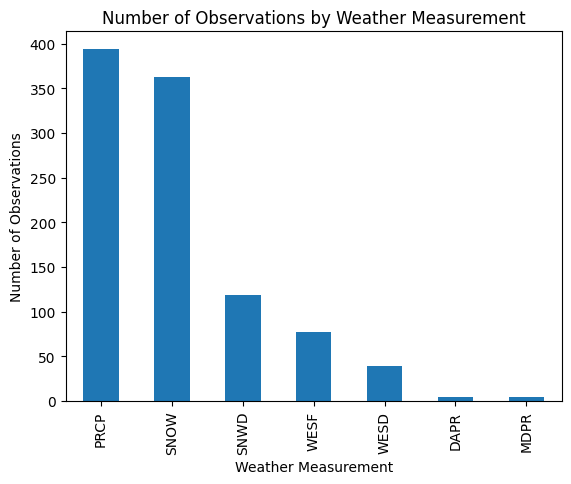

In [16]:
weather_df["datatype"].value_counts().plot(kind="bar")

plt.title("Number of Observations by Weather Measurement")
plt.xlabel("Weather Measurement")
plt.ylabel("Number of Observations")
plt.show()

# Visualization 2: Distribution of recorded values

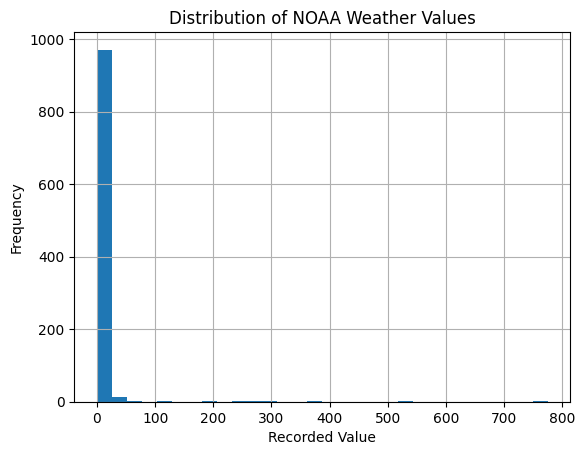

In [17]:
weather_df["value"].hist(bins=30)

plt.title("Distribution of NOAA Weather Values")
plt.xlabel("Recorded Value")
plt.ylabel("Frequency")
plt.show()

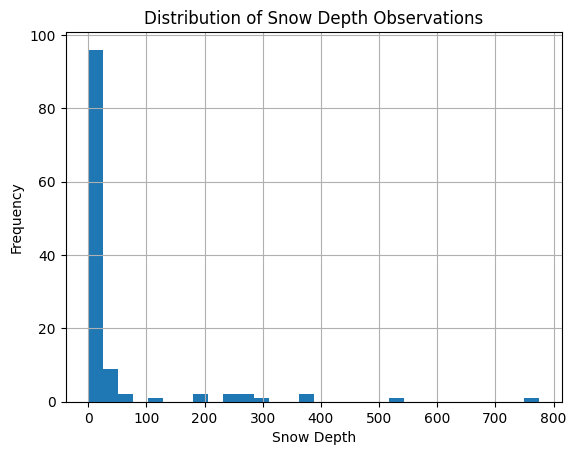

In [18]:
# Visualization 3: Snow depth only
snow_depth = weather_df[
    weather_df["datatype"] == "SNWD"
]

snow_depth["value"].hist(bins=30)

plt.title("Distribution of Snow Depth Observations")
plt.xlabel("Snow Depth")
plt.ylabel("Frequency")
plt.show()

EDA Review: The statewide request produces too many observations to retrieve Colorado's historical data through a simple 1,000-record API call.

# Build Dataframe to work with

Set the historical period — January 1, 2016 through December 31, 2025 for a clean 10-year period.

Focus - Use historical NOAA weather observations to predict daily snowfall (SNOW) in Colorado. Build a Regresion Model

In [24]:
# Which stations recorded the most snowfall in 2024?
snow_params = {
    "datasetid": "GHCND",
    "locationid": "FIPS:08",
    "datatypeid": "SNOW",
    "startdate": "2024-01-01",
    "enddate": "2024-12-31",
    "units": "metric",
    "limit": 1000
}

response = requests.get(
    f"{BASE_URL}/data",
    headers=headers,
    params=snow_params
)

print(response.status_code)

200


In [25]:
snow_2024 = pd.DataFrame(
    response.json()["results"]
)

snow_2024.head()

,date,datatype,station,attributes,value
0,2024-01-01T00:00:00,SNOW,GHCND:US1COAD0087,",,N,0700",0.0
1,2024-01-01T00:00:00,SNOW,GHCND:US1COAD0100,",,N,0700",0.0
2,2024-01-01T00:00:00,SNOW,GHCND:US1COAD0120,",,N,0700",0.0
3,2024-01-01T00:00:00,SNOW,GHCND:US1COAD0123,",,N,0700",0.0
4,2024-01-01T00:00:00,SNOW,GHCND:US1COAD0127,",,N,0700",0.0


In [26]:
print("Rows:", len(snow_2024))
print("Stations:", snow_2024["station"].nunique())

Rows: 1000
Stations: 954


In [27]:
response.json()["metadata"]["resultset"]

{'offset': 1, 'count': 307526, 'limit': 1000}

Pagination to retreive the complete 2024 snowfall data because only 1,000 records are retrieved from NOAA at a time.

In [28]:
all_snow_records = []

limit = 1000
total_records = 307526

for offset in range(1, total_records + 1, limit):

    snow_params = {
        "datasetid": "GHCND",
        "locationid": "FIPS:08",
        "datatypeid": "SNOW",
        "startdate": "2024-01-01",
        "enddate": "2024-12-31",
        "units": "metric",
        "limit": limit,
        "offset": offset
    }

    response = requests.get(
        f"{BASE_URL}/data",
        headers=headers,
        params=snow_params
    )

    response.raise_for_status()

    records = response.json().get("results", [])

    all_snow_records.extend(records)

print("Records downloaded:", len(all_snow_records))

Records downloaded: 307526


In [29]:
snow_2024 = pd.DataFrame(all_snow_records)

print("Shape:", snow_2024.shape)
print("Stations:", snow_2024["station"].nunique())

snow_2024.head()

Shape: (307526, 5)
Stations: 1433


,date,datatype,station,attributes,value
0,2024-01-01T00:00:00,SNOW,GHCND:US1COAD0087,",,N,0700",0.0
1,2024-01-01T00:00:00,SNOW,GHCND:US1COAD0100,",,N,0700",0.0
2,2024-01-01T00:00:00,SNOW,GHCND:US1COAD0120,",,N,0700",0.0
3,2024-01-01T00:00:00,SNOW,GHCND:US1COAD0123,",,N,0700",0.0
4,2024-01-01T00:00:00,SNOW,GHCND:US1COAD0127,",,N,0700",0.0


In [30]:
# Calculate total snowfall by stattion
snowfall_by_station = (
    snow_2024
    .groupby("station")["value"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

snowfall_by_station.head(50)


,station,value
0,GHCND:US1CODL0045,9337.0
1,GHCND:USC00051660,8781.0
2,GHCND:US1COGN0018,8234.0
3,GHCND:USC00059175,7891.0
4,GHCND:USC00050909,5911.0
5,GHCND:US1COCS0031,5907.0
6,GHCND:US1COSU0006,5854.0
7,GHCND:USC00057936,5785.0
8,GHCND:USC00051959,5482.0
9,GHCND:US1COSU0067,5412.0


In [31]:
station_summary = (
    snow_2024
    .groupby("station")
    .agg(
        total_snowfall=("value", "sum"),
        observations=("value", "count")
    )
    .sort_values(
        "total_snowfall",
        ascending=False
    )
    .reset_index()
)

station_summary.head(50)

,station,total_snowfall,observations
0,GHCND:US1CODL0045,9337.0,80
1,GHCND:USC00051660,8781.0,366
2,GHCND:US1COGN0018,8234.0,366
3,GHCND:USC00059175,7891.0,366
4,GHCND:USC00050909,5911.0,366
5,GHCND:US1COCS0031,5907.0,299
6,GHCND:US1COSU0006,5854.0,214
7,GHCND:USC00057936,5785.0,366
8,GHCND:USC00051959,5482.0,364
9,GHCND:US1COSU0067,5412.0,198


In [32]:
# Keep Stations based on similar volume of observations and then rank highest snowfall
reliable_stations = (
    station_summary[
        station_summary["observations"] >= 300
    ]
    .sort_values(
        "total_snowfall",
        ascending=False
    )
)

reliable_stations.head(50)

,station,total_snowfall,observations
1,GHCND:USC00051660,8781.0,366
2,GHCND:US1COGN0018,8234.0,366
3,GHCND:USC00059175,7891.0,366
4,GHCND:USC00050909,5911.0,366
7,GHCND:USC00057936,5785.0,366
8,GHCND:USC00051959,5482.0,364
10,GHCND:US1COJK0023,5384.0,312
13,GHCND:US1COJF0331,5025.0,354
14,GHCND:US1COLK0001,4998.0,347
15,GHCND:USC00050372,4993.0,366


In [33]:
print(
    "Stations with at least 300 observations:",
    len(reliable_stations)
)

Stations with at least 300 observations: 382


Include Colorado stations that reported at least 300 daily snowfall observations during 2024.

Colorado NOAA snowfall stations
        ↓
382 stations with ≥300 observations in 2024
        ↓
Retrieve historical data for 2016–2025
        ↓
Examine historical coverage
        ↓
Decide which stations have enough data
        ↓
Build modeling dataset

# Retrieve Historical Data from 2016- 2025.

Using 382 stations because these set of stations had at leats 300 observations in the 2024 year.

In [34]:
selected_stations = reliable_stations["station"].tolist()

print("Stations selected:", len(selected_stations))
print(selected_stations[:5])

Stations selected: 382
['GHCND:USC00051660', 'GHCND:US1COGN0018', 'GHCND:USC00059175', 'GHCND:USC00050909', 'GHCND:USC00057936']


In [36]:
historical_records = []

batch_size = 25

for year in range(2016, 2026):

    print("Downloading year:", year)

    # Break the 382 stations into smaller groups
    for i in range(0, len(selected_stations), batch_size):

        station_batch = selected_stations[i:i + batch_size]

        offset = 1

        while True:

            params = {
                "datasetid": "GHCND",
                "stationid": station_batch,
                "datatypeid": "SNOW",
                "startdate": f"{year}-01-01",
                "enddate": f"{year}-12-31",
                "units": "metric",
                "limit": 1000,
                "offset": offset
            }

            response = requests.get(
                f"{BASE_URL}/data",
                headers=headers,
                params=params
            )

            response.raise_for_status()

            results = response.json().get("results", [])

            historical_records.extend(results)

            # Fewer than 1000 means this batch has no more pages
            if len(results) < 1000:
                break

            offset += 1000

print("Download complete.")
print("Total observations:", len(historical_records))

Download complete.
Total observations: 1108213
